# Reinforcement Learning

### Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

### Environment


In [7]:
class TaxiChargingEnv(gym.Env):

    def __init__(self):

        super().__init__()

        # ---- Battery ----

        self.capacity = 50.0

        self.initial_soc = 20.0

        # ---- Time ----

        self.max_steps = 8      # 2h / 15 min

        self.current_step = 0

        # ---- Charging actions ----

        self.power_levels = [0, 5, 11, 22]

        self.action_space = spaces.Discrete(len(self.power_levels))

        # ---- State ----

        self.observation_space = spaces.Box(
            low=np.array([0,0]),
            high=np.array([50,8]),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.current_step = 0

        self.soc = self.initial_soc

        obs = np.array(
            [self.soc, self.current_step],
            dtype=np.float32
        )

        return obs, {}

    def step(self, action):

        power = self.power_levels[action]

        # 15 minutes = 0.25 h

        energy_added = power * 0.25

        self.soc = min(
            self.capacity,
            self.soc + energy_added
        )

        alpha = 0.01

        charging_cost = alpha * np.exp(power / 5)

        reward = -charging_cost

        self.current_step += 1

        terminated = False

        if self.current_step >= self.max_steps:

            demand = np.random.normal(
                loc=30,
                scale=5
            )

            if self.soc < demand:

                reward -= 1000

            else:

                reward += 100

            terminated = True

        obs = np.array(
            [self.soc, self.current_step],
            dtype=np.float32
        )

        return obs, reward, terminated, False, {}

In [8]:
env = TaxiChargingEnv()

check_env(env)

print("Environment valid.")

Environment valid.


In [9]:
env = TaxiChargingEnv()

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.001,
    buffer_size=10000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [10]:
model.learn(
    total_timesteps=50000
)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 8        |
|    ep_rew_mean      | 98.1     |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 11935    |
|    time_elapsed     | 0        |
|    total_timesteps  | 32       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 8        |
|    ep_rew_mean      | 97.7     |
|    exploration_rate | 0.988    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 15115    |
|    time_elapsed     | 0        |
|    total_timesteps  | 64       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 8        |
|    ep_rew_mean      | 6.26     |
|    exploration_rate | 0.982    |
| time/               |          |
|    episodes       

In [11]:
model.save("taxi_charging_dqn")

In [12]:
env = TaxiChargingEnv()

obs, _ = env.reset()

done = False

total_reward = 0

while not done:

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    obs, reward, done, _, _ = env.step(action)

    total_reward += reward

print("Reward:", total_reward)

Reward: 97.48929112176636


In [13]:
n_episodes = 1000

success = 0
rewards = []

for _ in range(n_episodes):

    obs, _ = env.reset()

    done = False
    total_reward = 0

    while not done:

        action, _ = model.predict(
            obs,
            deterministic=True
        )

        obs, reward, done, _, _ = env.step(action)

        total_reward += reward

    rewards.append(total_reward)

    if total_reward > 0:
        success += 1

print(f"Success rate: {success/n_episodes*100:.2f}%")
print(f"Average reward: {np.mean(rewards):.2f}")
print(f"Minimum reward: {np.min(rewards):.2f}")
print(f"Maximum reward: {np.max(rewards):.2f}")

Success rate: 94.20%
Average reward: 33.69
Minimum reward: -1002.51
Maximum reward: 97.49


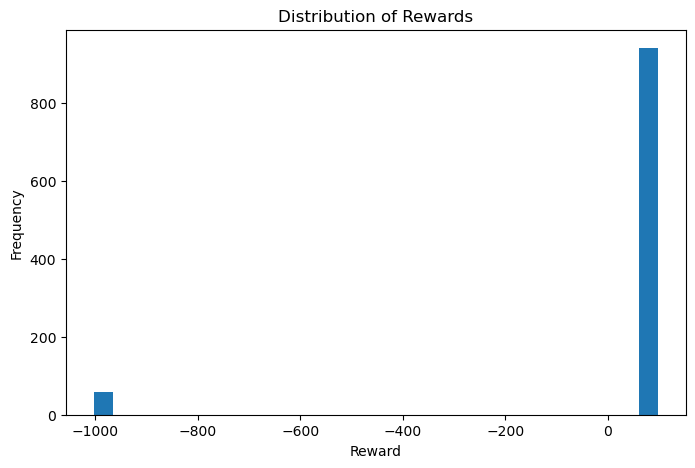

In [14]:
plt.figure(figsize=(8,5))

plt.hist(rewards, bins=30)

plt.title("Distribution of Rewards")
plt.xlabel("Reward")
plt.ylabel("Frequency")

plt.show()

In [15]:
action_counts = np.zeros(4)

obs, _ = env.reset()

done = False

while not done:

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    action_counts[action] += 1

    obs, reward, done, _, _ = env.step(action)

print(action_counts)

[4. 1. 0. 3.]


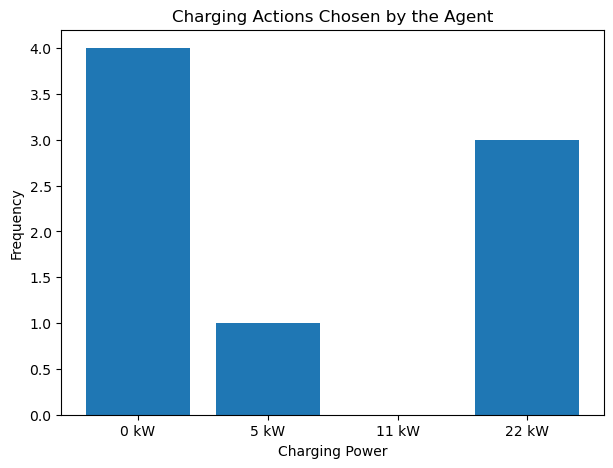

In [16]:
labels = [
    "0 kW",
    "5 kW",
    "11 kW",
    "22 kW"
]

plt.figure(figsize=(7,5))

plt.bar(labels, action_counts)

plt.title("Charging Actions Chosen by the Agent")
plt.xlabel("Charging Power")
plt.ylabel("Frequency")

plt.show()

In [17]:
obs, _ = env.reset()

done = False

step = 0

print("Step | Battery | Action")

while not done:

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    print(
        f"{step:>4} | "
        f"{obs[0]:>7.2f} kWh | "
        f"{env.power_levels[action]} kW"
    )

    obs, reward, done, _, _ = env.step(action)

    step += 1

print("\nFinal reward:", reward)

Step | Battery | Action
   0 |   20.00 kWh | 22 kW
   1 |   25.50 kWh | 22 kW
   2 |   31.00 kWh | 22 kW
   3 |   36.50 kWh | 0 kW
   4 |   36.50 kWh | 5 kW
   5 |   37.75 kWh | 0 kW
   6 |   37.75 kWh | 0 kW
   7 |   37.75 kWh | 0 kW

Final reward: -1000.01
